In [1]:
import os
import sys
path = os.getcwd()
while True:
    if 'utils.py' in os.listdir(path):
        if path not in sys.path:
            sys.path.append(path)
        break
    new_path = os.path.dirname(path)
    if new_path == path:
        upload_utils = files.upload()
        break
    path = new_path

import utils

/opt/anaconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.1_8B_Instruct/Results/checkpoint_mnli_m_Llama_3.1_8B_Instruct_8bit_zero_shot.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.1_8B_Instruct/Results/checkpoint_mnli_m_Llama_3.1_8B_Instruct_8bit_few_shot_1_examples_entailment.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.1_8B_Instruct/Results/checkpoint_mnli_m_Llama_3.1_8B_Instruct_8bit_few_shot_1_examples_contradiction.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.1_8B_Instruct/Results/checkpoint_mnli_m_Llama_3.1_8B_Instruct_8bit_few_shot_1_examples_neutral.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.1_8B_Instruct/Results/checkpoint_mnli_m_Llama_3.1_8B_Instruc

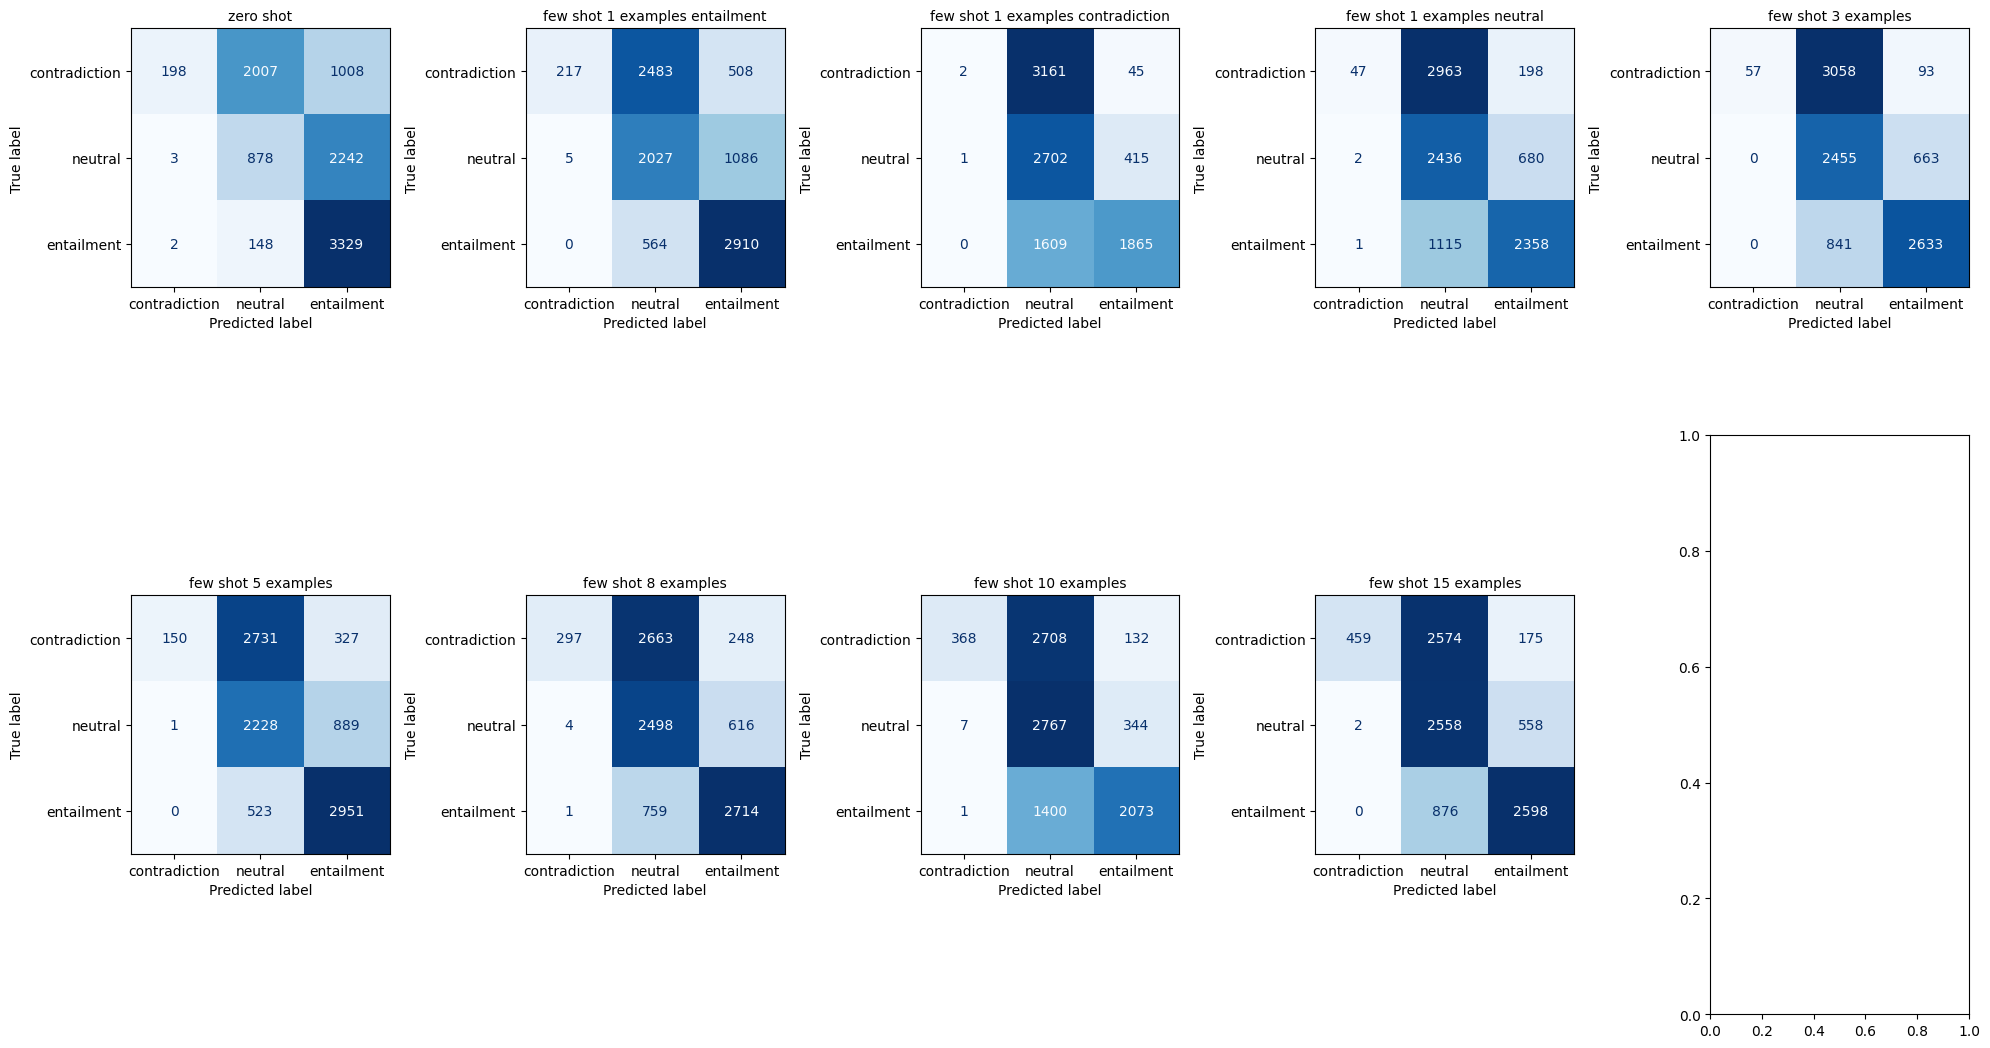

In [5]:
import matplotlib.pyplot as plt

training_modes = [
    'zero shot',
    'few shot 1 examples entailment',
    'few shot 1 examples contradiction',
    'few shot 1 examples neutral',
    'few shot 3 examples',
    'few shot 5 examples',
    'few shot 8 examples',
    'few shot 10 examples',
    'few shot 15 examples'    
]

fig, axes = plt.subplots(2, 5, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

for idx, mode in enumerate(training_modes):
    global_params = {'dataset_type': 'mnli_m',
                'quantization': '8bit',
                'training_mode': mode,
                'model_id': 'meta-llama/Llama-3.1-8B-Instruct'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
labels = [
    "0 examples",
    "1 example (entailment)",
    "1 example (contradiction)",
    '1 mm example (neutral)',
    "3 examples",
    "5 examples",
    "8 examples",
    "10 examples",
    "15 examples"
]

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
     "F1": f1s,
     "MCC": mccs,
     "Kappa": kappas},
     index= labels
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
0 examples,0.4488,0.5903,0.4332,0.3544,0.1928,0.1614
1 example (entailment),0.5259,0.6744,0.5185,0.4503,0.3243,0.2870
1 example (contradiction),0.4662,0.6101,0.4680,0.3849,0.2838,0.2071
1 mm example (neutral),0.4940,0.6809,0.4916,0.4125,0.2995,0.2445
3 examples,0.5250,0.7211,0.5210,0.4402,0.3509,0.2902
5 examples,0.5438,0.7027,0.5369,0.4600,0.3618,0.3152
8 examples,0.5621,0.7213,0.5583,0.4972,0.3990,0.3448
10 examples,0.5314,0.7315,0.5330,0.4825,0.3764,0.3028
15 examples,0.5730,0.7338,0.5704,0.5248,0.4167,0.3617


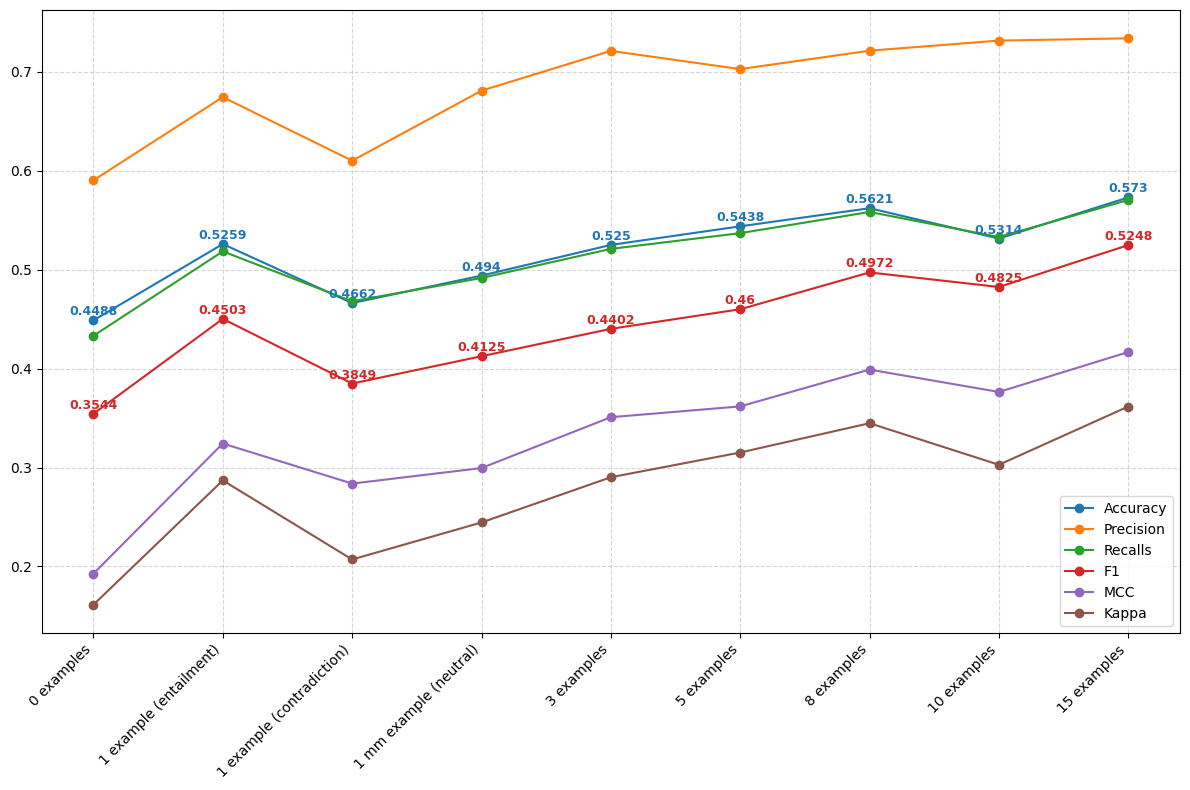

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df.index)))
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()

Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.1_8B_Instruct/Results/checkpoint_mnli_mm_Llama_3.1_8B_Instruct_8bit_zero_shot.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.1_8B_Instruct/Results/checkpoint_mnli_mm_Llama_3.1_8B_Instruct_8bit_few_shot_1_m_examples_entailment.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.1_8B_Instruct/Results/checkpoint_mnli_mm_Llama_3.1_8B_Instruct_8bit_few_shot_1_m_examples_contradiction.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.1_8B_Instruct/Results/checkpoint_mnli_mm_Llama_3.1_8B_Instruct_8bit_few_shot_1_m_examples_neutral.pt
Checkpoint found.
Saving to: /Users/georgedikaios/Desktop/DAMA_EAP/NLI_Study/Notebooks/MNLI_Notebooks/MNLI_Llama_3.1_8B_Instruct/Results/checkpoint_mnli_mm_Llama_3.1

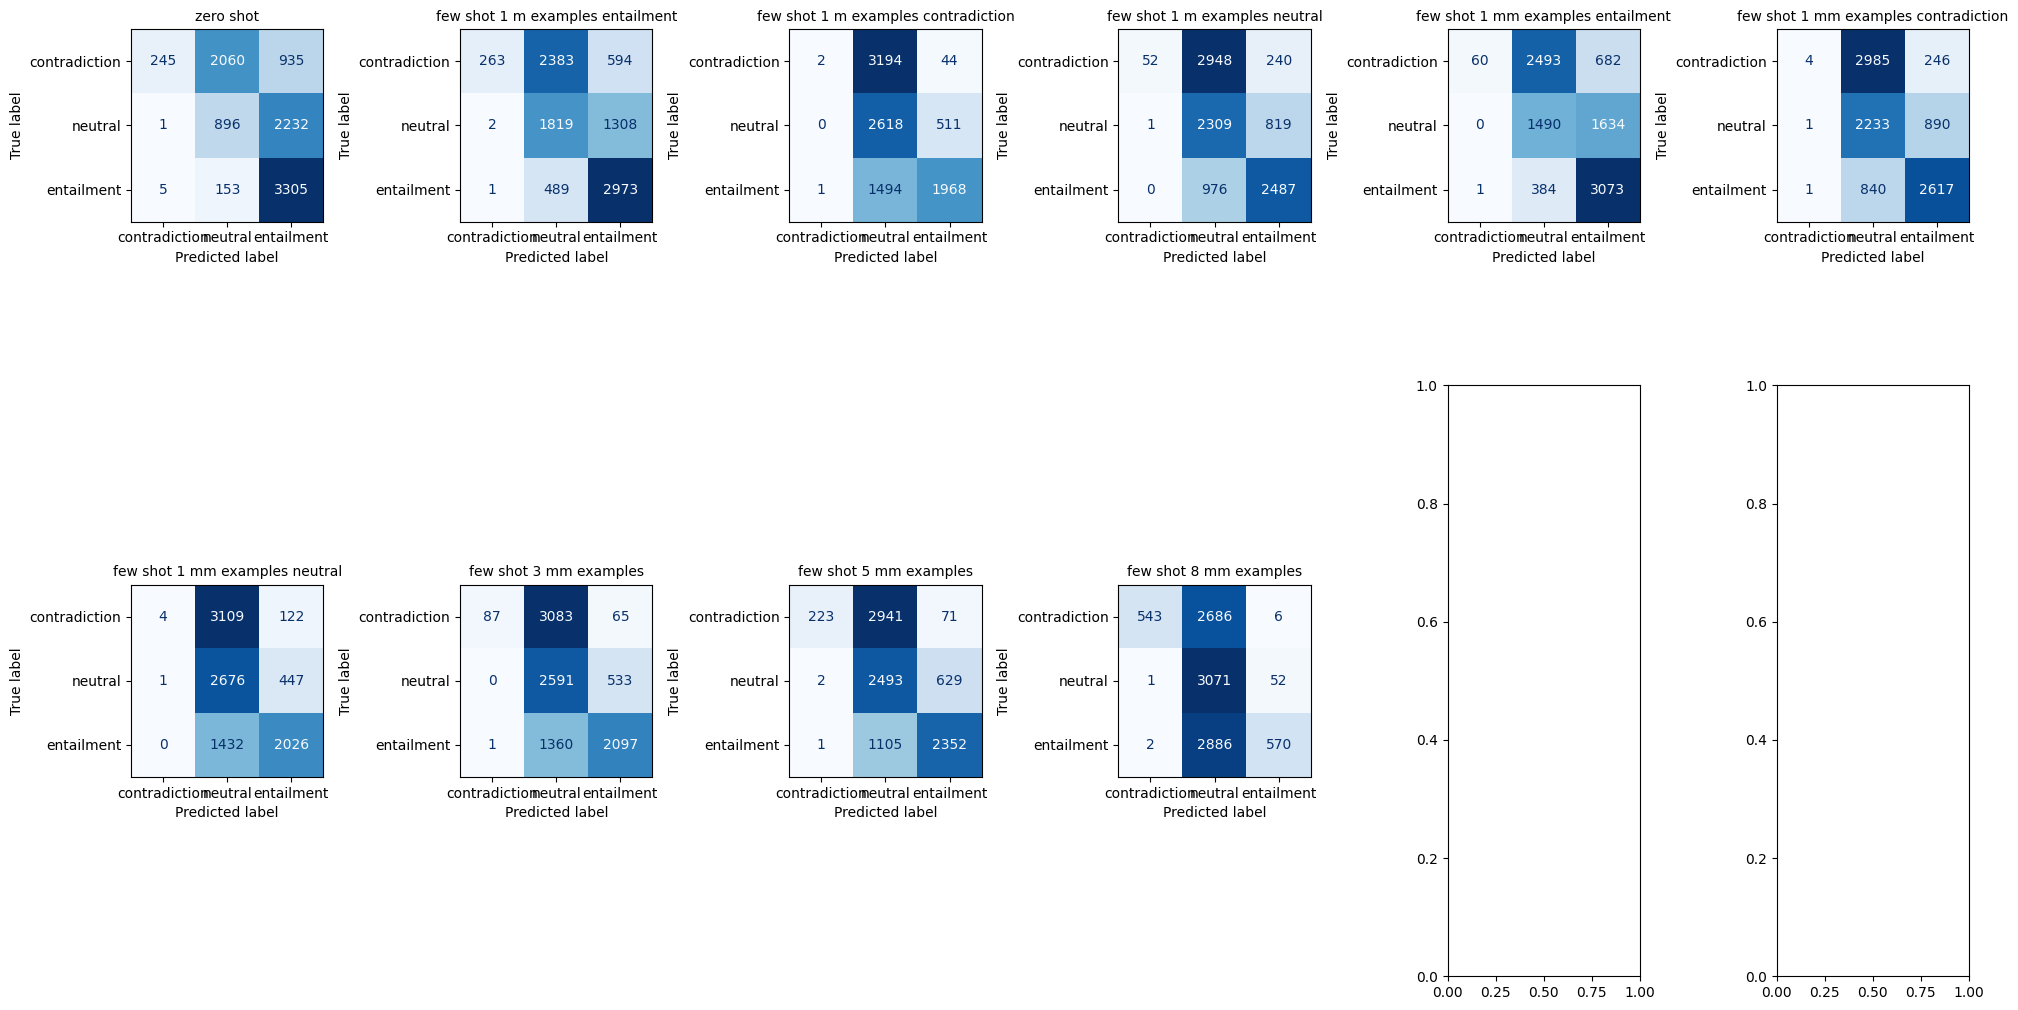

In [12]:
import matplotlib.pyplot as plt

training_modes = [
    'zero shot',
    'few shot 1 m examples entailment',
    'few shot 1 m examples contradiction',
    'few shot 1 m examples neutral',
    'few shot 1 mm examples entailment',
    'few shot 1 mm examples contradiction',
    'few shot 1 mm examples neutral',
    'few shot 3 mm examples',
    'few shot 5 mm examples',
    'few shot 8 mm examples',
    # 'few shot 10 mm examples',
    # 'few shot 15 mm examples'    
]

fig, axes = plt.subplots(2, 6, figsize=(20,12))
axes = axes.flatten()
accs, precisions, recalls, f1s, mccs, kappas = [], [], [], [], [], []

for idx, mode in enumerate(training_modes):
    global_params = {'dataset_type': 'mnli_mm',
                'quantization': '8bit',
                'training_mode': mode,
                'model_id': 'meta-llama/Llama-3.1-8B-Instruct'}
   
    checkpoint_path = utils.create_checkpoint_path(params=global_params)
    predicted_labels, gold_labels, _ = utils.load_checkpoint(checkpoint_path)

    acc, precision, recall, f1, mcc, kappa = utils.get_metrics(
                                            predicted_labels=predicted_labels,
                                            gold_labels=gold_labels,
                                            params=global_params,
                                            ax=axes[idx]
                                            )   
    accs.append(round(acc, 4))
    precisions.append(round(precision, 4))
    recalls.append(round(recall, 4))
    f1s.append(round(f1, 4))
    mccs.append(round(mcc, 4))
    kappas.append(round(kappa, 4))

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
labels = [
    "0 examples",
    "1 m example (entailment)",
    "1 m example (contradiction)",
    '1 m example (neutral)',
    "1 mm example (entailment)",
    "1 mm example (contradiction)",
    '1 mm example (neutral)',
    "3 mm examples",
    "5 mm examples",
    "8 mm examples",
    # "10 mm examples",
    # "15 mm examples"
]

metrics_df = pd.DataFrame(
    {"Accuracy": accs,
     "Precision": precisions,
     "Recalls": recalls,
     "F1": f1s,
     "MCC": mccs,
     "Kappa": kappas},
     index= labels
)
metrics_df

,Accuracy,Precision,Recalls,F1,MCC,Kappa
0 examples,0.4522,0.5917,0.4388,0.3643,0.1998,0.1689
1 m example (entailment),0.5141,0.6621,0.5070,0.4428,0.3020,0.2689
1 m example (contradiction),0.4666,0.6017,0.4685,0.3868,0.2769,0.2075
1 m example (neutral),0.4931,0.6843,0.4907,0.4115,0.2911,0.2428
1 mm example (entailment),0.4709,0.6317,0.4614,0.3763,0.2319,0.2020
1 mm example (contradiction),0.4944,0.5775,0.4909,0.4049,0.2908,0.2440
1 mm example (neutral),0.4794,0.6505,0.4812,0.3965,0.2986,0.2262
3 mm examples,0.4864,0.7117,0.4876,0.4147,0.3033,0.2361
5 mm examples,0.5162,0.7129,0.5157,0.4558,0.3385,0.2790
8 mm examples,0.4262,0.7525,0.4386,0.3627,0.2762,0.1549


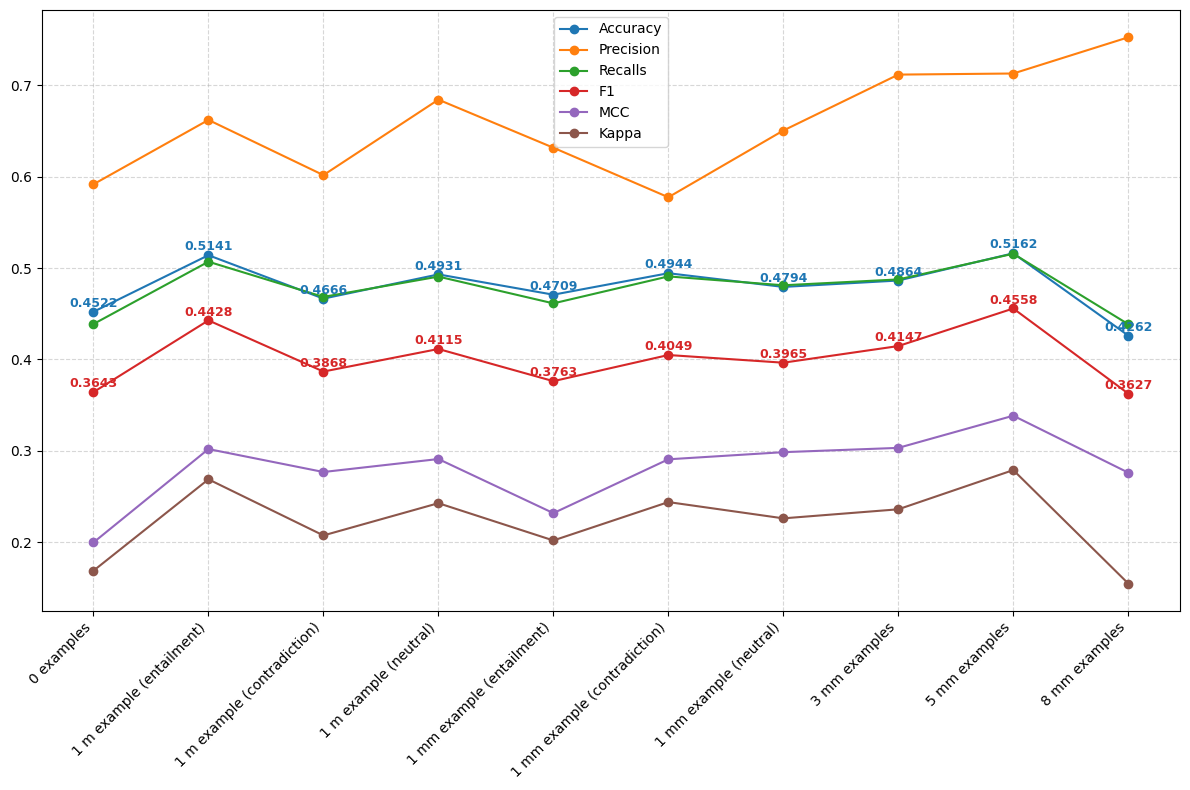

In [14]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot all metrics
metrics_df.plot(kind='line', ax=ax, marker='o')

# set custom x-axis labels
ax.set_xticks(range(len(metrics_df.index)))
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')

# show grid
ax.grid(True, linestyle='--', alpha=0.5)

# annotate only Accuracy and F1
for metric in ["Accuracy", "F1"]:
    for x, y in enumerate(metrics_df[metric]):
        ax.text(x, y + 0.002, str(y), ha='center', va='bottom', fontsize=9, fontweight='bold', color=ax.get_lines()[list(metrics_df.columns).index(metric)].get_color())

plt.tight_layout()
plt.show()